# 06 完整诊断流程与健康基线

**本节目标**

1. 用 `DiagnosisPipeline` 对四类故障信号做端到端自动诊断，验证分类正确性；
2. 用 `HealthBaseline` 演示马氏距离：以健康样本建立基线，
   量化待测样本偏离健康状态的程度。

**背景**（详见 [docs/07 故障判别与诊断流程](../docs/07_diagnosis.md)）

诊断分两条互补的路径：

1. **谱峰匹配（定位故障部位）**：在包络谱上检索四类故障特征频率的 1–3 次谐波，
   命中峰幅值与噪声地板（幅值中位数）之比作为显著性得分，得分最高者为诊断结论，
   全部低于阈值则判健康；
2. **马氏距离（判断是否异常）**：用若干健康样本的特征向量估计基线分布
   $\mathcal{N}(\mu, \Sigma)$，待测样本的马氏距离
   $D = \sqrt{(x-\mu)^\top \Sigma^{-1} (x-\mu)}$
   反映其偏离健康状态的程度。

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bearing_fault import (BearingSimulator, DiagnosisPipeline, HealthBaseline,
                           time_domain_features)
from bearing_fault.plotting import FAULT_LABELS, plot_envelope_report, plot_scores

FS, RPM, DURATION = 12000, 1797, 3.0
pipe = DiagnosisPipeline(fs=FS)

## 端到端诊断：四类故障各跑一次

`DiagnosisPipeline.run(x, rpm)` 一行完成"包络分析 → 特征频率计算 → 谱峰匹配"，
返回包含结论、得分、命中峰等完整信息的诊断报告。

In [2]:
faults = ["inner", "outer", "ball", "cage"]
reports = {}
rows = {}
for fault in faults:
    x = BearingSimulator(fs=FS, duration=DURATION, rpm=RPM, seed=42).signal(fault)
    report = pipe.run(x, RPM)
    reports[fault] = report
    rows[FAULT_LABELS[fault]] = {**{k: round(v, 1) for k, v in report.scores.items()},
                                 "verdict": report.verdict}

df = pd.DataFrame(rows).T
df

,cage,ball,inner,outer,verdict
内圈故障,8.2,9.7,94.3,39.1,inner
外圈故障,6.7,42.3,39.6,111.5,outer
滚动体故障,22.1,94.9,23.1,35.6,ball
保持架故障,58.8,49.0,19.4,39.4,cage


得分含义：该类故障各谐波命中峰的"峰/噪声地板"倍数的平均值。
最高得分对应诊断结论（verdict）。看诊断报告中的包络谱与得分分布：

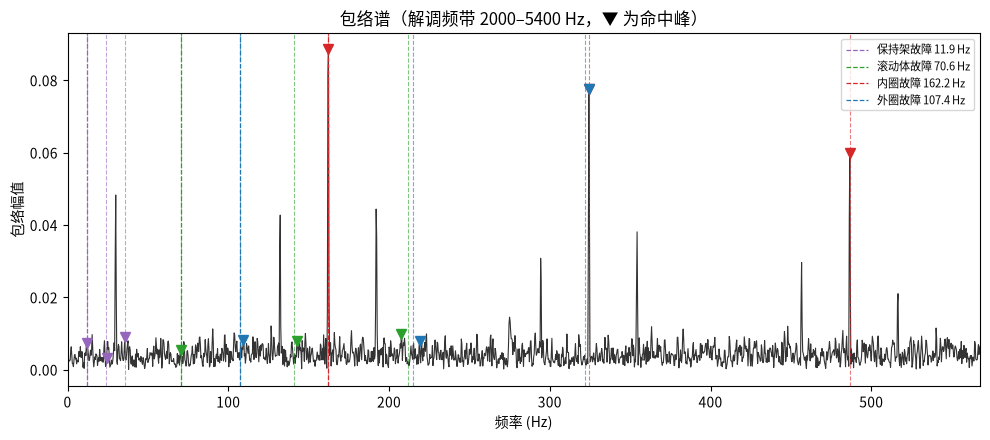

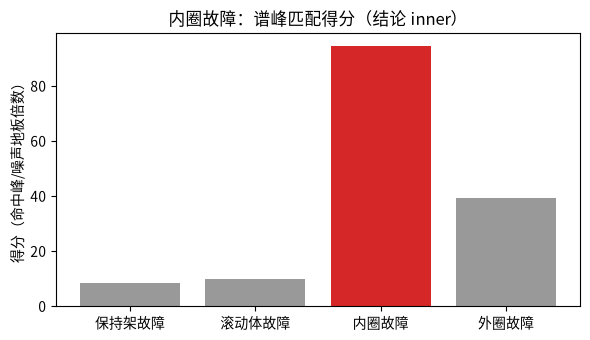

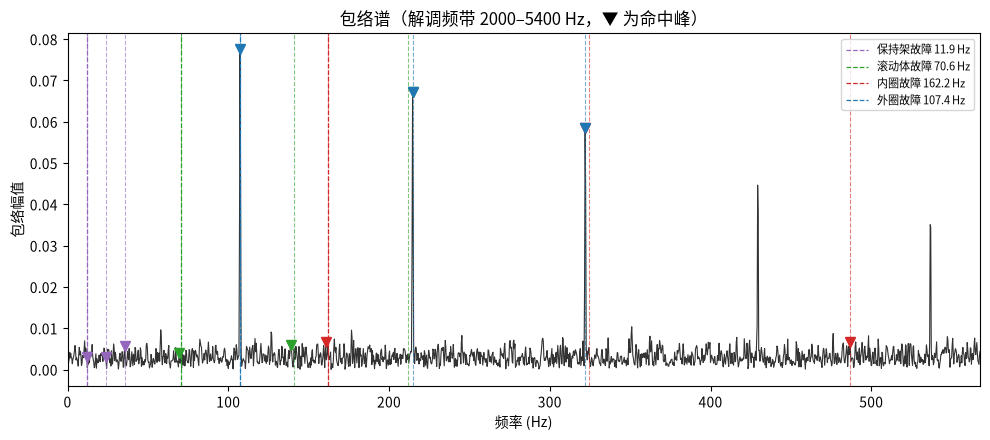

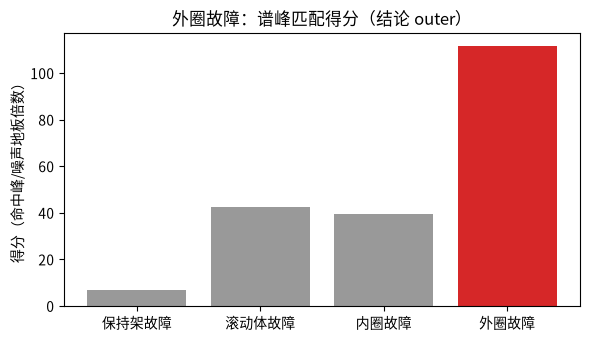

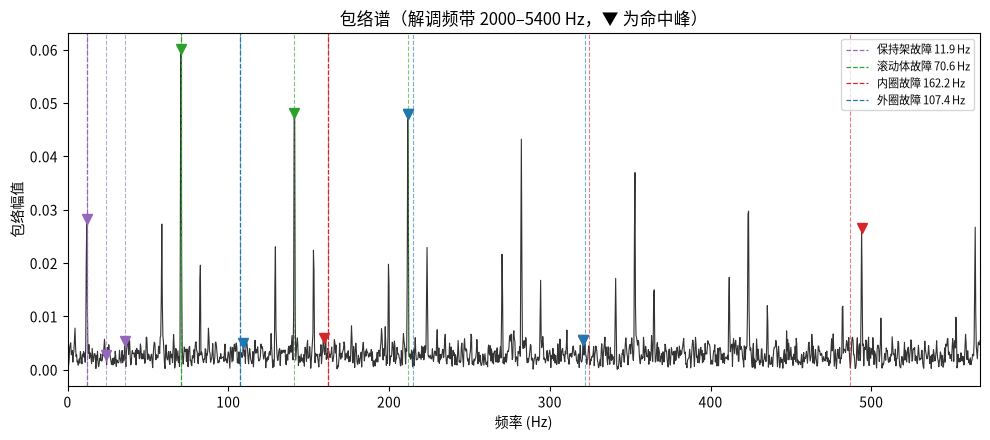

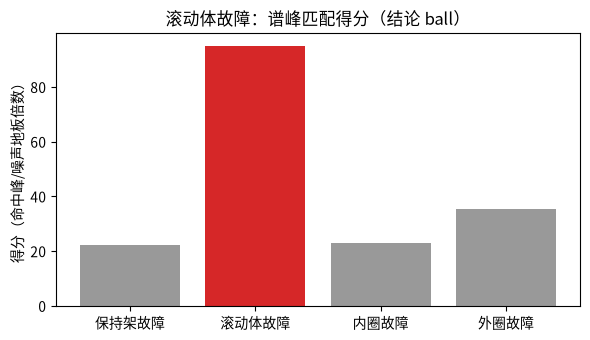

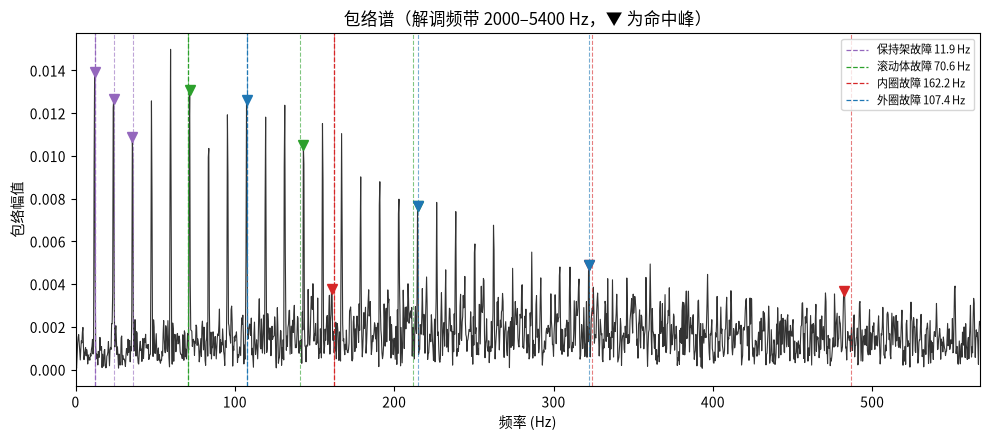

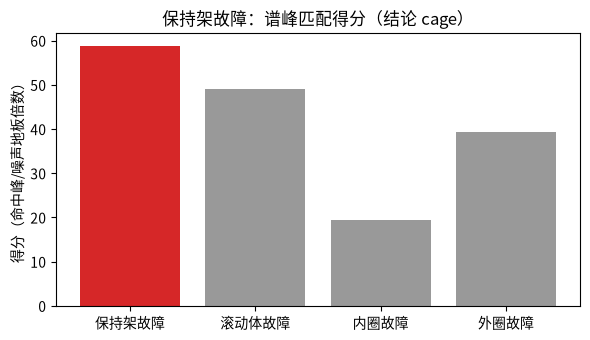

In [3]:
for fault in faults:
    r = reports[fault]
    plot_envelope_report(r)
    plot_scores(r.scores, r.verdict,
                title=f"{FAULT_LABELS[fault]}：谱峰匹配得分（结论 {r.verdict}）")
plt.show()

In [4]:
ok = all(reports[f].verdict == f for f in faults)
for f in faults:
    print(f"注入故障 {f:6s} → 诊断结论 {reports[f].verdict:6s} "
          f"(最强峰相对误差 {reports[f].peak_error()*100:.2f}%)")
assert ok, "存在误诊！"
print("\n四类故障全部诊断正确 ✔")

注入故障 inner  → 诊断结论 inner  (最强峰相对误差 0.09%)
注入故障 outer  → 诊断结论 outer  (最强峰相对误差 0.03%)
注入故障 ball   → 诊断结论 ball   (最强峰相对误差 0.12%)
注入故障 cage   → 诊断结论 cage   (最强峰相对误差 0.59%)

四类故障全部诊断正确 ✔


## 健康基线与马氏距离

谱峰匹配能定位故障部位，但需要先知道轴承型号与转速。
马氏距离提供另一条路径：只用**健康样本**建立基线，不依赖任何故障先验，
回答"这段信号离健康状态有多远"。

1. 用 10 个不同随机种子的健康样本拟合基线（特征取 RMS、峭度、峰值因子、
   脉冲因子、峰峰值这 5 个对冲击敏感且物理意义明确的指标）；
2. 计算新的健康样本与故障样本到基线的马氏距离。

In [5]:
FEATURE_NAMES = ["rms", "kurtosis", "crest_factor", "impulse_factor", "peak_to_peak"]

def feats(fault, seed):
    x = BearingSimulator(fs=FS, duration=DURATION, rpm=RPM, seed=seed).signal(fault)
    return time_domain_features(x)

baseline = HealthBaseline(FEATURE_NAMES).fit([feats("healthy", s) for s in range(10)])

samples = {"健康×3": [feats("healthy", 100 + i) for i in range(3)]}
for f in faults:
    samples[FAULT_LABELS[f]] = [feats(f, 200), feats(f, 201)]

names, dists = [], []
for label, feats_list in samples.items():
    for f_dict in feats_list:
        names.append(label)
        dists.append(baseline.distance(f_dict))

for n, d in zip(names, dists):
    print(f"{n:8s} 马氏距离 = {d:10.1f}")

健康×3     马氏距离 =        1.5
健康×3     马氏距离 =        3.2
健康×3     马氏距离 =        5.0
内圈故障     马氏距离 =     1284.5
内圈故障     马氏距离 =     1293.3
外圈故障     马氏距离 =      875.9
外圈故障     马氏距离 =      873.2
滚动体故障    马氏距离 =      763.3
滚动体故障    马氏距离 =      764.6
保持架故障    马氏距离 =      364.1
保持架故障    马氏距离 =      383.1


把距离画成柱状图（纵轴取对数）：健康样本的距离在个位数量级，
故障样本高出几个数量级——用一条很宽的阈值带就能把两者分开。

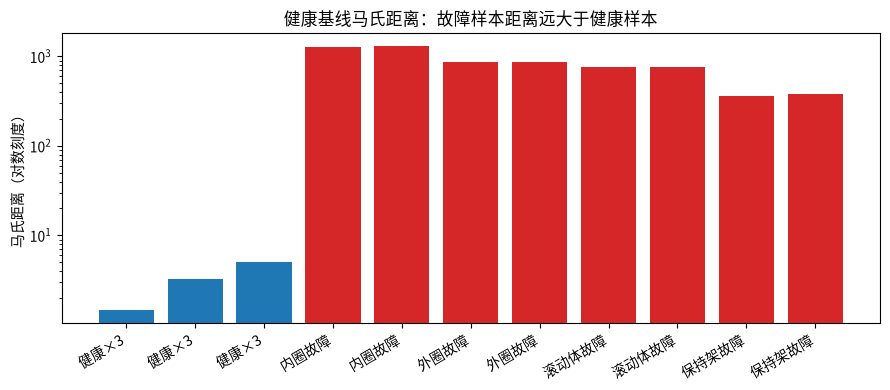

健康样本距离范围：1.5 – 5.0
故障样本距离范围：364.1 – 1293.3


In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
colors = ["tab:blue" if n.startswith("健康") else "tab:red" for n in names]
ax.bar(range(len(dists)), dists, color=colors)
ax.set_xticks(range(len(dists)), names, rotation=30, ha="right")
ax.set_yscale("log")
ax.set_ylabel("马氏距离（对数刻度）")
ax.set_title("健康基线马氏距离：故障样本距离远大于健康样本")
fig.tight_layout()
plt.show()

healthy_d = [d for n, d in zip(names, dists) if n.startswith("健康")]
fault_d = [d for n, d in zip(names, dists) if not n.startswith("健康")]
print(f"健康样本距离范围：{min(healthy_d):.1f} – {max(healthy_d):.1f}")
print(f"故障样本距离范围：{min(fault_d):.1f} – {max(fault_d):.1f}")
assert max(healthy_d) < min(fault_d)

**小结**

- 谱峰匹配：依赖轴承型号与转速，能**定位**故障部位（内/外圈、滚动体、保持架）；
- 马氏距离：只需健康数据建基线，能灵敏地**发现**异常，但不能定位；
- 工程实践中两者结合：先用马氏距离做低成本在线监测，触发报警后再用
  包络谱 + 谱峰匹配做精确定位。

至此 6 个 notebook 覆盖了从信号仿真 → 特征提取 → 包络分析 →
阶次/时频分析 → 自动诊断的完整链条，对应 docs/ 01–07 章的理论讲解。